# Busca Semântica em Avaliações de Produtos (NLP)

Este notebook desenvolve um pequeno sistema de **Processamento de Linguagem Natural (NLP)** capaz de analisar, organizar e **recuperar informações textuais de forma semântica**.

Usamos uma base real de avaliações de e-commerce em **português** (B2W-Reviews01) para demonstrar como **embeddings vetoriais** permitem buscas inteligentes baseadas no *significado* do texto, e não apenas nas palavras exatas.

Ao longo do processo faremos: inspeção dos dados, limpeza básica do texto, extração de termos frequentes, representação semântica com embeddings, agrupamento (clustering) e, por fim, uma **busca por similaridade** que recupera avaliações parecidas com uma consulta escrita em linguagem natural.

In [ ]:
# Instala as dependências necessárias para este notebook
%pip install sentence-transformers wordcloud nltk -q

In [1]:
# Importações principais usadas ao longo do notebook
import re
import pandas as pd                 # manipulação de DataFrame
import numpy as np

import matplotlib.pyplot as plt     # visualização básica
import seaborn as sns               # visualizações estatísticas

from wordcloud import WordCloud     # gerar nuvem de palavras

import nltk
from nltk.corpus import stopwords   # lista de stopwords (palavras muito comuns)

from sentence_transformers import SentenceTransformer        # modelo para embeddings
from sklearn.feature_extraction.text import CountVectorizer  # contagem de tokens e n-gramas
from sklearn.cluster import KMeans                           # clusterização com K-Means
from sklearn.decomposition import PCA                        # redução dimensional (PCA)
from sklearn.metrics.pairwise import cosine_similarity       # similaridade entre vetores

# Baixa a lista de stopwords do NLTK (executar apenas uma vez por ambiente)
nltk.download('stopwords')

c:\Users\paulo\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\paulo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 1. Carregamento e inspeção inicial

Carregamos o arquivo `B2W-Reviews01.csv`, que contém avaliações de produtos feitas por clientes em português. Essa primeira leitura serve para identificar as colunas disponíveis, o tamanho da base e ver uma amostra dos registros antes de qualquer tratamento.

As colunas mais importantes para o nosso objetivo são:

- `review_text` — o **texto** da avaliação (foco da análise de NLP);
- `review_title` — o título curto da avaliação;
- `site_category_lv1` — a **categoria** do produto;
- `overall_rating` — a **nota** de 1 a 5;
- `recommend_to_a_friend` — se o cliente recomendaria o produto.

In [2]:
# Carrega o dataset de avaliações (encoding UTF-8; low_memory=False evita aviso de tipos mistos)
df = pd.read_csv('B2W-Reviews01.csv', low_memory=False)

# Mostra a dimensão (linhas, colunas)
print(df.shape)

# Mostra as primeiras linhas
df.head()

(132373, 14)


,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,overall_rating,recommend_to_a_friend,review_text,reviewer_birth_year,reviewer_gender,reviewer_state
0,2018-01-01 00:11:28,d0fb1ca69422530334178f5c8624aa7a99da47907c44de...,132532965,Notebook Asus Vivobook Max X541NA-GO472T Intel...,NaN,Informática,Notebook,Bom,4,Yes,Estou contente com a compra entrega rápida o ú...,1958.0,F,RJ
1,2018-01-01 00:13:48,014d6dc5a10aed1ff1e6f349fb2b059a2d3de511c7538a...,22562178,Copo Acrílico Com Canudo 500ml Rocie,NaN,Utilidades Domésticas,"Copos, Taças e Canecas","Preço imbatível, ótima qualidade",4,Yes,"Por apenas R$1994.20,eu consegui comprar esse ...",1996.0,M,SC
2,2018-01-01 00:26:02,44f2c8edd93471926fff601274b8b2b5c4824e386ae4f2...,113022329,Panela de Pressão Elétrica Philips Walita Dail...,philips walita,Eletroportáteis,Panela Elétrica,ATENDE TODAS AS EXPECTATIVA.,4,Yes,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...,1984.0,M,SP
3,2018-01-01 00:35:54,ce741665c1764ab2d77539e18d0e4f66dde6213c9f0863...,113851581,Betoneira Columbus - Roma Brinquedos,roma jensen,Brinquedos,Veículos de Brinquedo,presente mais que desejado,4,Yes,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...,1985.0,F,SP
4,2018-01-01 01:00:28,7d7b6b18dda804a897359276cef0ca252f9932bf4b5c8e...,131788803,"Smart TV LED 43"" LG 43UJ6525 Ultra HD 4K com C...",lg,TV e Home Theater,TV,"Sem duvidas, excelente",5,Yes,"A entrega foi no prazo, as americanas estão de...",1994.0,M,MG


In [3]:
# Mostra informações do DataFrame: nomes das colunas, tipos e contagem de valores não nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132373 entries, 0 to 132372
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   submission_date        132373 non-null  object 
 1   reviewer_id            132373 non-null  object 
 2   product_id             132373 non-null  object 
 3   product_name           132289 non-null  object 
 4   product_brand          40982 non-null   object 
 5   site_category_lv1      132367 non-null  object 
 6   site_category_lv2      128360 non-null  object 
 7   review_title           132071 non-null  object 
 8   overall_rating         132373 non-null  int64  
 9   recommend_to_a_friend  132355 non-null  object 
 10  review_text            129098 non-null  object 
 11  reviewer_birth_year    126389 non-null  float64
 12  reviewer_gender        128237 non-null  object 
 13  reviewer_state         128382 non-null  object 
dtypes: float64(1), int64(1), object(12)


## 2. Qualidade dos dados e estatísticas descritivas

Aqui verificamos se existem valores ausentes e analisamos estatísticas resumidas da base. O objetivo é entender a qualidade dos dados antes de avançar para a análise textual. Como o foco é o texto, removemos as avaliações sem `review_text`.

In [4]:
# Conta valores ausentes por coluna para identificar o que precisa de limpeza
missing = df.isnull().sum()

# Mostra apenas as colunas com valores ausentes, em ordem decrescente
missing[missing > 0].sort_values(ascending=False)

product_brand            91391
reviewer_birth_year       5984
reviewer_gender           4136
site_category_lv2         4013
reviewer_state            3991
review_text               3275
review_title               302
product_name                84
recommend_to_a_friend       18
site_category_lv1            6
dtype: int64

In [5]:
# Remove linhas sem texto de avaliação (não servem para a análise de NLP)
df = df.dropna(subset=['review_text']).reset_index(drop=True)

print('Avaliações com texto:', df.shape[0])

# Estatísticas descritivas das colunas numéricas (ex.: distribuição das notas)
df.describe()

Avaliações com texto: 129098


,overall_rating,reviewer_birth_year
count,129098.000000,123321.000000
mean,3.520744,1977.536762
std,1.516784,22.063783
min,1.000000,59.000000
25%,2.000000,1969.000000
50%,4.000000,1980.000000
75%,5.000000,1987.000000
max,5.000000,2018.000000


## 3. Distribuição das variáveis categóricas

Os gráficos abaixo mostram como as avaliações se distribuem por **categoria de produto**, por **nota** e por **recomendação**. Essa visão ajuda a entender a composição da base antes de mergulhar no texto.

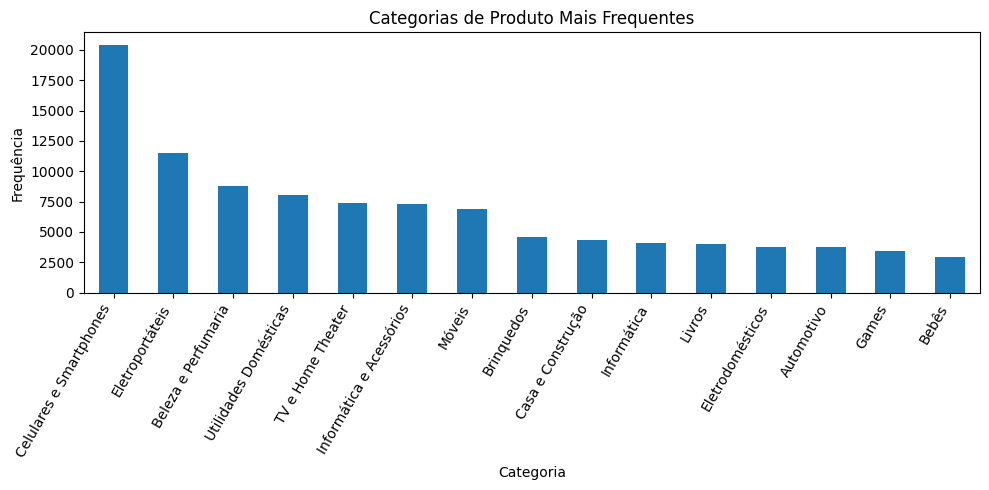

In [6]:
# Gráfico de barras com as 15 categorias de produto mais frequentes
plt.figure(figsize=(10, 5))

df['site_category_lv1'].value_counts().head(15).plot(kind='bar')

plt.title('Categorias de Produto Mais Frequentes')
plt.xlabel('Categoria')
plt.ylabel('Frequência')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

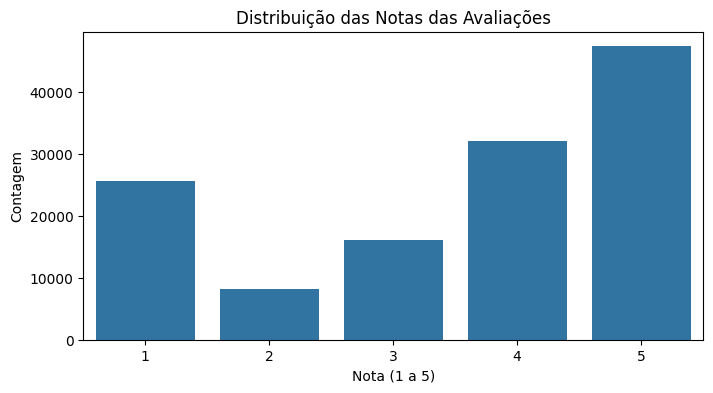

In [7]:
# Distribuição das notas (overall_rating), de 1 a 5
plt.figure(figsize=(8, 4))

sns.countplot(data=df, x='overall_rating')

plt.title('Distribuição das Notas das Avaliações')
plt.xlabel('Nota (1 a 5)')
plt.ylabel('Contagem')
plt.show()

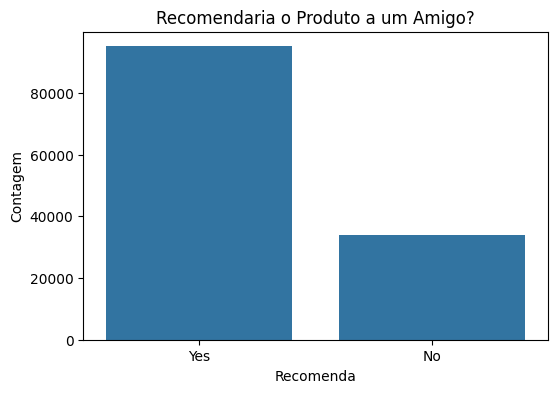

In [8]:
# Distribuição da intenção de recomendar o produto a um amigo
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='recommend_to_a_friend')

plt.title('Recomendaria o Produto a um Amigo?')
plt.xlabel('Recomenda')
plt.ylabel('Contagem')
plt.show()

## 4. Preparação do texto

Selecionamos a coluna `review_text` e aplicamos uma limpeza básica para padronizar o texto: converter para minúsculas, remover pontuação e números, e eliminar **stopwords** em português (palavras muito comuns como *de*, *que*, *para*, que carregam pouco significado). Diferente do inglês, mantemos as letras acentuadas (á, ã, ç, é, ...), que são essenciais no português.

In [9]:
# Seleciona a coluna de interesse e garante que não há valores nulos
texts = df['review_text'].fillna('').astype(str)

# Visualiza os primeiros textos
texts.head()

0    Estou contente com a compra entrega rápida o ú...
1    Por apenas R$1994.20,eu consegui comprar esse ...
2    SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...
3    MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...
4    A entrega foi no prazo, as americanas estão de...
Name: review_text, dtype: object

In [10]:
# Carrega as stopwords em português do NLTK
stop_words = set(stopwords.words('portuguese'))

# Função para normalizar e remover ruído do texto
def clean_text(text):
    # garante string e converte para minúsculas
    text = str(text).lower()

    # mantém apenas letras (incluindo acentuadas) e espaços
    text = re.sub(r'[^a-zà-ÿ\s]', ' ', text)

    # separa em tokens por espaços
    tokens = text.split()

    # remove stopwords e palavras muito curtas
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]

    # junta os tokens em uma string limpa
    return ' '.join(tokens)

# Aplica a limpeza em todas as avaliações e guarda em uma nova coluna
df['clean_text'] = texts.apply(clean_text)

In [11]:
# Compara lado a lado: texto original e texto limpo (para validar a função)
df[['review_text', 'clean_text']].head()

,review_text,clean_text
0,Estou contente com a compra entrega rápida o ú...,contente compra entrega rápida único problema ...
1,"Por apenas R$1994.20,eu consegui comprar esse ...",apenas consegui comprar lindo copo acrílico
2,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...,supera agilidade praticidade outras panelas el...
3,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...,filho amou parece verdade tantos detalhes têm
4,"A entrega foi no prazo, as americanas estão de...",entrega prazo americanas parabéns smart boa na...


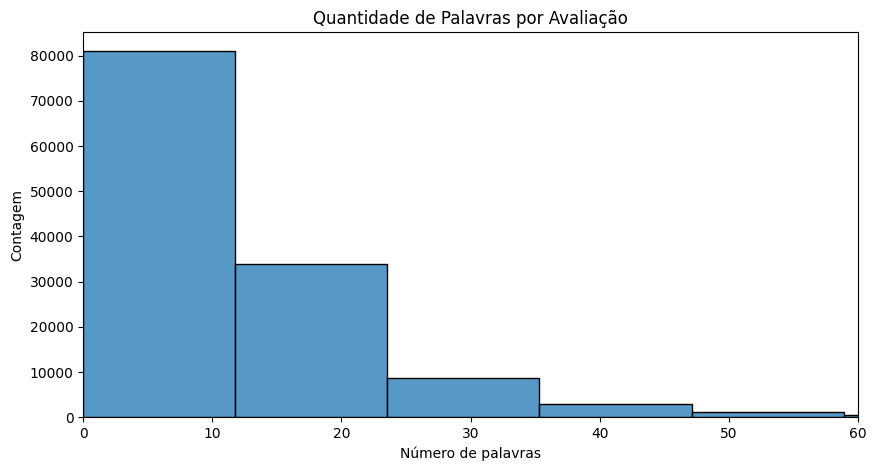

In [12]:
# Calcula o tamanho dos textos limpos (em número de palavras) e plota um histograma
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))

# Limita o eixo x para focar na maioria das avaliações (curtas)
sns.histplot(df['text_length'], bins=40)
plt.xlim(0, 60)

plt.title('Quantidade de Palavras por Avaliação')
plt.xlabel('Número de palavras')
plt.ylabel('Contagem')
plt.show()

## 5. Frequência de termos e expressões

Depois da limpeza, contamos as palavras mais recorrentes e também os **bigramas** (pares de palavras) para enxergar padrões de linguagem nas avaliações. Isso ajuda a descobrir quais termos e combinações aparecem com mais frequência e a entender os assuntos mais comuns.

In [13]:
# Extrai os termos mais frequentes com CountVectorizer
vectorizer = CountVectorizer(max_features=30)

# Matriz documento-termo (esparsa)
X = vectorizer.fit_transform(df['clean_text'])

# Soma as colunas direto na matriz esparsa (sem converter para densa, que gastaria muita memória)
freq = pd.DataFrame({
    'palavra': vectorizer.get_feature_names_out(),
    'freq': np.asarray(X.sum(axis=0)).ravel()
}).sort_values(by='freq', ascending=False)

freq.head(20)

,palavra,freq
21,produto,71753
6,bom,26009
24,recomendo,24891
13,entrega,23188
4,bem,17024
22,qualidade,16769
7,chegou,16323
19,prazo,15979
14,excelente,14624
2,antes,12451


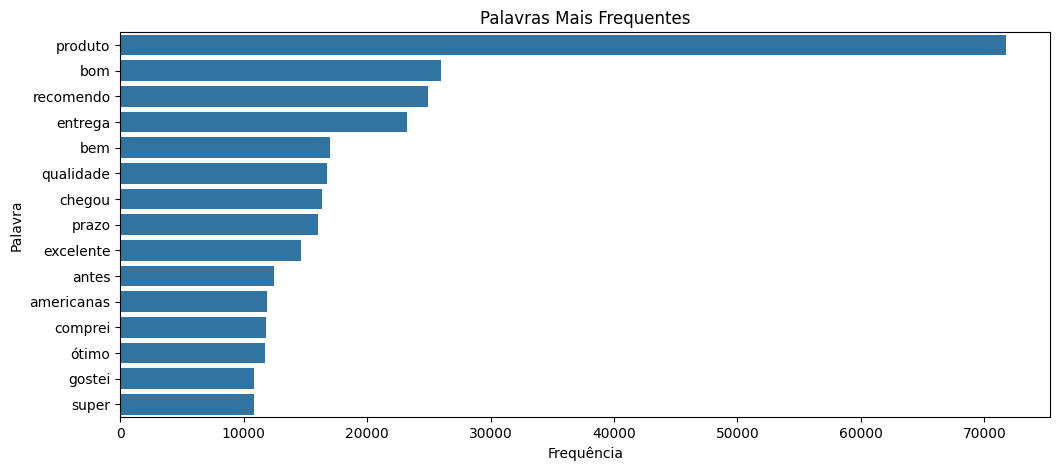

In [14]:
# Plota as 15 palavras mais frequentes
plt.figure(figsize=(12, 5))

sns.barplot(data=freq.head(15), x='freq', y='palavra')

plt.title('Palavras Mais Frequentes')
plt.xlabel('Frequência')
plt.ylabel('Palavra')
plt.show()

In [ ]:
# Gera a nuvem de palavras diretamente a partir dos textos já limpos.
# O próprio WordCloud conta as frequências, então não precisamos do CountVectorizer aqui.
texto_completo = ' '.join(df['clean_text'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(texto_completo)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [16]:
# Extrai os bigramas (pares de palavras) mais frequentes
vectorizer_bi = CountVectorizer(ngram_range=(2, 2), max_features=20)

X_bi = vectorizer_bi.fit_transform(df['clean_text'])

# Soma direto na matriz esparsa (mesmo motivo das células anteriores)
bigrams = pd.DataFrame({
    'bigrama': vectorizer_bi.get_feature_names_out(),
    'freq': np.asarray(X_bi.sum(axis=0)).ravel()
}).sort_values(by='freq', ascending=False)

bigrams.head(15)

,bigrama,freq
0,antes prazo,7423
12,produto bom,6197
3,chegou antes,4199
6,entrega rápida,3761
13,produto chegou,3608
15,recebi produto,3556
17,super recomendo,3356
14,produto excelente,3312
9,gostei produto,3251
18,ótima qualidade,3123


## 6. Representação semântica com embeddings

Agora chegamos ao coração do sistema. Transformamos cada avaliação em um **vetor numérico (embedding)** usando um modelo pré-treinado **multilíngue**, que entende português. Textos com significado parecido ficam **próximos** nesse espaço vetorial, mesmo que usem palavras diferentes.

Como esse cálculo é mais custoso, usamos uma **amostra de 5.000 avaliações**. Em seguida, projetamos os vetores em 2 dimensões com PCA apenas para conseguir visualizá-los.

In [17]:
# Carrega um modelo de embeddings multilíngue (entende português)
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Amostra para reduzir o custo computacional (ajuste conforme necessário)
sample = df.sample(5000, random_state=42).reset_index(drop=True)

# Calcula os embeddings a partir do texto original das avaliações
embeddings = model.encode(
    sample['review_text'].tolist(),
    show_progress_bar=True
)

print('Formato da matriz de embeddings:', embeddings.shape)

Batches: 100%|██████████| 157/157 [02:55<00:00,  1.12s/it]

Formato da matriz de embeddings: (5000, 384)


In [18]:
# Reduz os embeddings para 2 dimensões com PCA, apenas para visualização
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

sample['x'] = coords[:, 0]
sample['y'] = coords[:, 1]

## 7. Visualização da distribuição semântica

O gráfico de dispersão mostra as avaliações projetadas no plano 2D, coloridas pela **categoria** do produto. Mesmo com a perda de informação da redução dimensional, já é possível observar que avaliações de assuntos parecidos tendem a ocupar regiões próximas do espaço semântico. Para não poluir a visualização, mostramos apenas as 6 categorias mais frequentes.

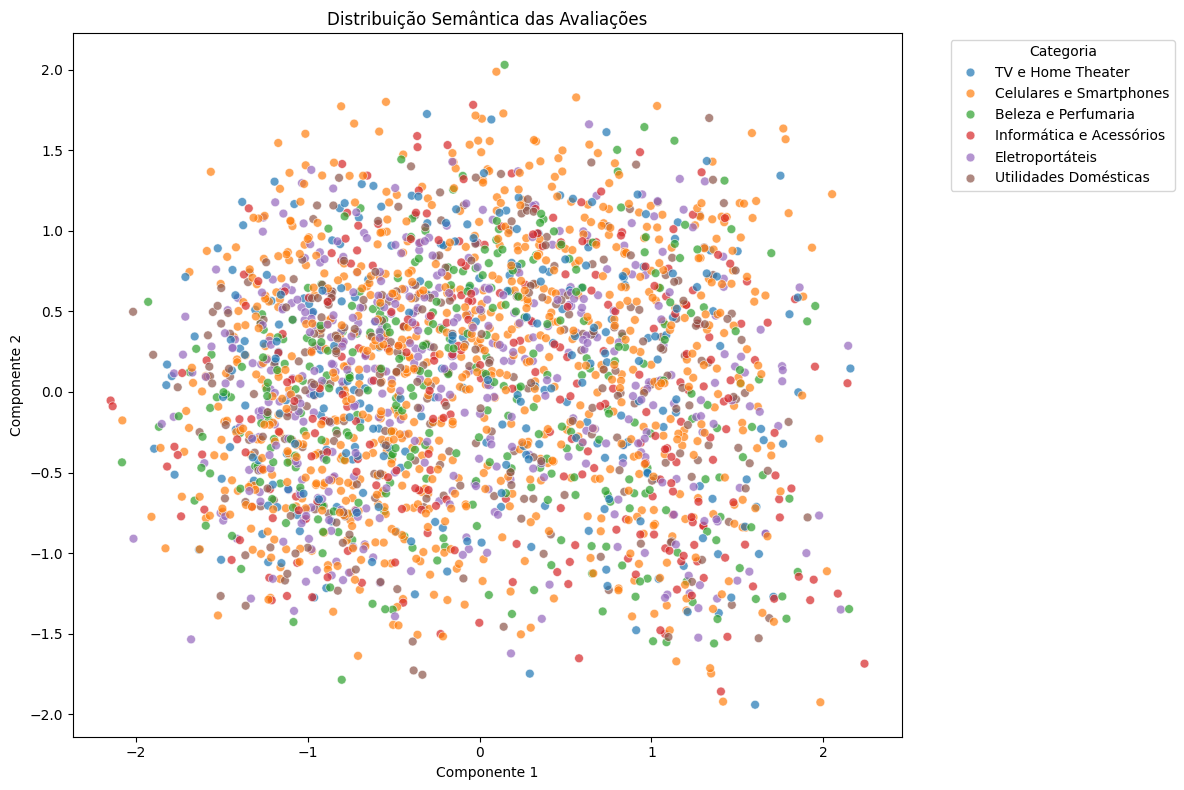

In [19]:
# Seleciona as 6 categorias mais frequentes da amostra para deixar o gráfico legível
top_cats = sample['site_category_lv1'].value_counts().head(6).index
subset = sample[sample['site_category_lv1'].isin(top_cats)]

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=subset,
    x='x',
    y='y',
    hue='site_category_lv1',
    s=40,
    alpha=0.7
)

plt.title('Distribuição Semântica das Avaliações')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8. Agrupamento semântico com K-Means

Com os embeddings calculados, aplicamos **K-Means** para separar as avaliações em grupos com conteúdo parecido, sem usar a categoria original. Essa segmentação é útil para descobrir padrões recorrentes e organizar grandes volumes de texto automaticamente.

In [20]:
# Agrupa os embeddings em 8 clusters
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
sample['cluster'] = kmeans.fit_predict(embeddings)

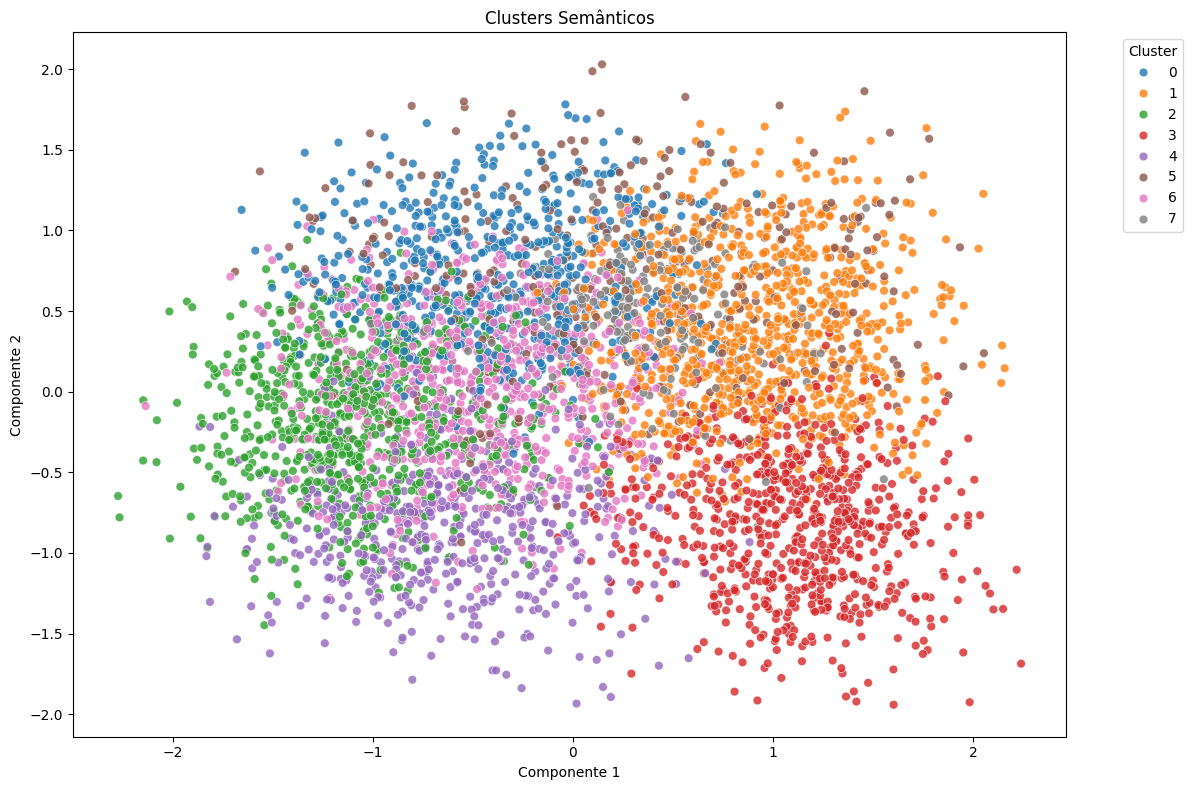

In [21]:
# Visualiza os clusters na projeção 2D
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=sample,
    x='x',
    y='y',
    hue='cluster',
    palette='tab10',
    s=40,
    alpha=0.8
)

plt.title('Clusters Semânticos')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [22]:
# Mostra exemplos de avaliações de cada cluster para interpretar os grupos
for c in sorted(sample['cluster'].unique()):
    exemplos = sample[sample['cluster'] == c]['review_text'].head(3).tolist()
    print(f'\n===== CLUSTER {c} =====')
    for txt in exemplos:
        print(' -', txt[:120])


===== CLUSTER 0 =====
 - Suporte muito bom. Veio com varias opções de fixação e aguenta TV’s grandes. Valeu super a pena. Fácil instalação, segui
 - O aparelho é bom, mas os produtos que o acompanham são fracos , Por exemplo Fone e Carregador. OBS: a câmera não é das m
 - Bonito, robusto, facil de limpar, extremamente decorativo.

===== CLUSTER 1 =====
 - Não veio como o combinado. Veio outra imagem. Não recomendo.
 - Simplesmente péssimo.  Muito instável. É anunciado com várias funcionalidades, mas para que ele fique utilizável, você t
 - Estou decepcionada! Precisava do lustre com urgencia, e chegou uma cor literalmente diferente a foto! Ele é mais pra um 

===== CLUSTER 2 =====
 - O produto é bom, recomendo, bom de tamanho, não toma muito espaço.
 - Amei o produto, super  recomendo! Chegou muito rápido.
 - Excelente qualidade útil bonito potente seguro e prático

===== CLUSTER 3 =====
 - o preço está correto?? R$ 10.000,00 ou 10x de R$ 1.000,00.
 - Bom dia! Minha experiência a prin

## 9. Busca por similaridade (recuperação semântica)

Esta é a demonstração principal do trabalho. Escrevemos uma **consulta em linguagem natural**, transformamos essa consulta em um embedding e usamos a **similaridade do cosseno** para recuperar as avaliações mais próximas em significado.

Repare que a busca funciona pelo **sentido**, e não pelas palavras exatas: uma consulta como *"o produto chegou quebrado"* recupera avaliações que falam de defeito, dano ou avaria, mesmo que não contenham exatamente essas palavras.

In [23]:
# Função de busca semântica: recebe uma consulta e retorna as avaliações mais parecidas
def buscar(query, top_n=5):
    # transforma a consulta em embedding
    query_embedding = model.encode([query])

    # calcula a similaridade do cosseno entre a consulta e todas as avaliações
    similarities = cosine_similarity(query_embedding, embeddings)[0]

    # pega os índices das avaliações mais similares
    top_idx = similarities.argsort()[-top_n:][::-1]

    # monta o resultado com a pontuação de similaridade
    resultado = sample.iloc[top_idx][[
        'site_category_lv1', 'overall_rating', 'review_title', 'review_text'
    ]].copy()
    resultado['similaridade'] = similarities[top_idx].round(3)
    return resultado

# Exemplo 1: consulta sobre problema de entrega
buscar('o produto chegou quebrado e com defeito')

,site_category_lv1,overall_rating,review_title,review_text,similaridade
4991,Eletroportáteis,1,O produto veio quebrado em várias partes.,"O produto veio quebrado em várias partes, a em...",0.828
2533,Saúde,3,até gostei...,"O produto veio furado, então não da pra aprove...",0.782
3364,Informática e Acessórios,1,Veio Quebrado,Recebi o produto todo cheio de cola e sem func...,0.774
949,Móveis,1,"Defeitos, quebras e falta de material.","Produto fora entregue com prateleira quebrada,...",0.773
3095,Eletroportáteis,1,Defeito,"Produto veio com defeito, e não consigo usar. ...",0.772


In [24]:
# Exemplo 2: consulta sobre demora na entrega
buscar('demorou muito tempo para entregar')

,site_category_lv1,overall_rating,review_title,review_text,similaridade
4341,Esporte e Lazer,3,Bom produto,"A entrega foi muito demorada, passou muito do ...",0.783
3866,Esporte e Lazer,2,Demora na entrega,Demorou tanto pra ser entregue que perdi a cha...,0.693
4773,Celulares e Smartphones,2,Entrega poderia ser mais rápido,"Foi dentro do prazo, mas deveria ser mais rápi...",0.605
4187,Beleza e Perfumaria,2,Não gostei muito.,Sei que não é original mas pensei que esquenta...,0.597
2552,Bebês,3,Excelente Pomada,"Apesar de ser mais complicada de passar, e óti...",0.590


In [25]:
# Exemplo 3: consulta positiva sobre custo-benefício
buscar('ótimo preço, vale muito a pena')

,site_category_lv1,overall_rating,review_title,review_text,similaridade
304,Celulares e Smartphones,5,Excelente,Muito bom gostei muito valeu a pena e o preç...,0.887
2595,Beleza e Perfumaria,5,Perfume,"Muito Bom, com um custo benefício maravilhoso,...",0.852
1914,Bebês,3,Bom produto,"Gostei, recomendo! Excelente custo beneficio. ...",0.844
1613,Eletroportáteis,4,Gostei bastante do produto.,De qualidade muito boa com um preço justo. Rec...,0.843
1618,Beleza e Perfumaria,4,Muito bom,Gostei muito da fixação é boa e o preço maravi...,0.819


## Conclusão

Este notebook combinou análise exploratória e processamento de linguagem natural para entender e organizar avaliações de produtos em português a partir de diferentes ângulos: inspeção dos dados, distribuição das categorias e notas, limpeza textual, frequência de termos, representação semântica com embeddings, clusterização e busca por similaridade.

A etapa final demonstra o objetivo central do trabalho: usar **embeddings vetoriais** e **similaridade do cosseno** para realizar uma **busca semântica**, recuperando informações pelo seu *significado* e não apenas pelas palavras exatas. Esse mesmo princípio é a base de sistemas modernos de recuperação de conhecimento (motores de busca semânticos, assistentes e bancos de dados vetoriais) aplicados a grandes volumes de texto.